# 05 — Quick CNN Evaluation (Fixed Rasterization)

**Goal:** Fast comparison of three XGBoost feature sets after rasterization fix:
- **Model A:** 5 geometric features (baseline)
- **Model B:** 5 geometric + 4 CNN embedding features  
- **Model C:** 5 geometric + 1 CNN logit feature (P(touching) from classification head)

**Speed tricks vs `04_cnn_embeddings.ipynb`:**
- **Single CNN trained once** on 85% of CV pool (no 16-fold LOBO for CNN)
- Embeddings extracted for the remaining 15% + Taiwan holdout
- **Stratified 5-fold CV** for XGBoost (balanced splits, not basin-based LOBO)
- Fewer CNN epochs (15 vs 40), lower patience (4 vs 8)

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.model_selection import LeaveOneGroupOut
from torch.utils.data import DataLoader
from xgboost import XGBClassifier

from channel_heads.cnn_model import (
    DEFAULT_EMBEDDING_DIM,
    OutletCNN,
    OutletPairDataset,
)
from channel_heads.config import PROJECT_ROOT
from channel_heads.geometric_analysis import default_stream_loader
from channel_heads.rasterizer import NUM_CLASSES, precompute_raster_dataset

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

# Paths
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
MASTER_CSV = RESULTS_DIR / "master_dataset_v2.csv"

# Holdout
HOLDOUT_BASIN = "taiwan"

# --- Speed-tuned CNN hyperparams ---
TARGET_SIZE = 128
EMBEDDING_DIM = 4
CNN_EPOCHS = 15          # was 40
CNN_LR = 1e-3
CNN_WEIGHT_DECAY = 1e-4
CNN_BATCH_SIZE = 64
CNN_DROPOUT = 0.3
PATIENCE = 4             # was 8

# XGBoost features
GEOM_FEATURES = [
    "orientation_diff_deg",
    "headhead_dist_norm",
    "apex_angle_deg",
    "strahler_order_diff",
    "proximity_profile_norm",
]

device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
print(f"Master CSV: {MASTER_CSV}")

Device: mps
Master CSV: /Users/guypi/Projects/channel-heads/data/results/master_dataset_v2.csv


## 1. Load Data & Rasters

In [2]:
# Load master dataset
df_master = pd.read_csv(MASTER_CSV)
print(f"Master: {len(df_master):,} rows, {df_master['basin'].nunique()} basins, "
      f"{df_master['y'].mean():.1%} touching")

# Check / compute rasters
raster_manifest_path = RESULTS_DIR / "raster_manifest.csv"
if raster_manifest_path.exists():
    print("Loading existing raster manifest...")
    df_raster = pd.read_csv(raster_manifest_path)
else:
    print("Pre-computing rasters (one-time cost)...")
    df_raster = precompute_raster_dataset(
        master_csv=MASTER_CSV,
        output_dir=RESULTS_DIR,
        dem_loader=default_stream_loader,
        target_size=TARGET_SIZE,
        threshold=300,
    )
    df_raster.to_csv(raster_manifest_path, index=False)

n_valid = df_raster["raster_path"].notna().sum()
print(f"Rasters: {n_valid}/{len(df_raster)} valid")

# Filter to usable rows
df_all = df_raster[df_raster["raster_path"].notna()].copy().reset_index(drop=True)

# Split CV / holdout
df_cv = df_all[df_all["basin"] != HOLDOUT_BASIN].copy().reset_index(drop=True)
df_ho = df_all[df_all["basin"] == HOLDOUT_BASIN].copy().reset_index(drop=True)
print(f"CV pool: {len(df_cv):,} rows ({df_cv['basin'].nunique()} basins)")
print(f"Holdout: {len(df_ho):,} rows ({HOLDOUT_BASIN})")

Master: 5,922 rows, 17 basins, 39.1% touching
Loading existing raster manifest...
Rasters: 5922/5922 valid
CV pool: 3,193 rows (16 basins)
Holdout: 2,729 rows (taiwan)


## 2. Train a Single CNN (fast)

Train one CNN on ~85% of the CV pool (random split, stratified by basin).
Extract embeddings + logit for **all** CV rows and Taiwan holdout.

**Note:** This introduces minor CNN-level leakage for the ~85% train rows
(the CNN saw them during training). This is fine for a quick directional test —
the full `04_cnn_embeddings.ipynb` does proper per-fold CNN training.

In [3]:
def train_cnn_fast(df_train, df_val, device="cpu"):
    """Train CNN with speed-tuned hyperparameters. Returns trained model."""
    ds_train = OutletPairDataset(df_train["raster_path"].tolist(), df_train["y"].values, augment=True)
    ds_val = OutletPairDataset(df_val["raster_path"].tolist(), df_val["y"].values, augment=False)
    loader_train = DataLoader(ds_train, batch_size=CNN_BATCH_SIZE, shuffle=True)
    loader_val = DataLoader(ds_val, batch_size=CNN_BATCH_SIZE, shuffle=False)

    model = OutletCNN(in_channels=NUM_CLASSES, embedding_dim=EMBEDDING_DIM, dropout=CNN_DROPOUT).to(device)

    n_pos = df_train["y"].sum()
    n_neg = len(df_train) - n_pos
    pos_weight = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=CNN_LR, weight_decay=CNN_WEIGHT_DECAY)

    best_val_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(CNN_EPOCHS):
        model.train()
        for images, labels in loader_train:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(images).squeeze(1), labels)
            loss.backward()
            optimizer.step()

        model.eval()
        val_losses = []
        with torch.no_grad():
            for images, labels in loader_val:
                images, labels = images.to(device), labels.to(device)
                val_losses.append(criterion(model(images).squeeze(1), labels).item())

        avg_val = np.mean(val_losses) if val_losses else float("nan")
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % 5 == 0:
            print(f"  Epoch {epoch+1:3d}/{CNN_EPOCHS}: val_loss={avg_val:.4f}")

        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    if best_state:
        model.load_state_dict(best_state)
    model.eval()
    return model


def extract_features(model, df_subset, device="cpu"):
    """Extract both 4-dim embeddings AND 1-dim logit (P(touching)) for each sample."""
    ds = OutletPairDataset(df_subset["raster_path"].tolist(), df_subset["y"].values, augment=False)
    loader = DataLoader(ds, batch_size=CNN_BATCH_SIZE, shuffle=False)

    all_emb, all_logit = [], []
    with torch.no_grad():
        for images, _ in loader:
            images = images.to(device)
            all_emb.append(model.embed(images).cpu().numpy())
            all_logit.append(torch.sigmoid(model(images).squeeze(1)).cpu().numpy())

    return np.vstack(all_emb), np.concatenate(all_logit)


print("Functions defined.")

Functions defined.


In [4]:
# Random 85/15 split for CNN training (stratified by basin to keep diversity)
rng = np.random.default_rng(RANDOM_STATE)
val_frac = 0.15
val_size = max(int(len(df_cv) * val_frac), 10)
perm = rng.permutation(len(df_cv))
val_idx = perm[:val_size]
train_idx = perm[val_size:]

df_cnn_train = df_cv.iloc[train_idx]
df_cnn_val = df_cv.iloc[val_idx]

print(f"CNN train: {len(df_cnn_train):,} rows ({df_cnn_train['y'].mean():.1%} touching)")
print(f"CNN val:   {len(df_cnn_val):,} rows ({df_cnn_val['y'].mean():.1%} touching)")
print(f"\nTraining single CNN ({CNN_EPOCHS} epochs max, patience={PATIENCE})...")

model = train_cnn_fast(df_cnn_train, df_cnn_val, device=device)
print("Done.")

CNN train: 2,715 rows (40.1% touching)
CNN val:   478 rows (35.8% touching)

Training single CNN (15 epochs max, patience=4)...
  Epoch   1/15: val_loss=0.7763
  Epoch   6/15: val_loss=0.6330
  Epoch  11/15: val_loss=0.7233
Done.


In [5]:
# Extract features for ALL CV rows + Taiwan holdout
print("Extracting embeddings + logits for CV pool...")
cv_emb, cv_logit = extract_features(model, df_cv, device=device)
print("Extracting embeddings + logits for Taiwan holdout...")
ho_emb, ho_logit = extract_features(model, df_ho, device=device)

# Add to DataFrames
emb_cols = [f"emb_{i}" for i in range(EMBEDDING_DIM)]
for i, col in enumerate(emb_cols):
    df_cv[col] = cv_emb[:, i]
    df_ho[col] = ho_emb[:, i]
df_cv["cnn_logit"] = cv_logit
df_ho["cnn_logit"] = ho_logit

print(f"\nCV embeddings: {cv_emb.shape}, logits: {cv_logit.shape}")
print(f"HO embeddings: {ho_emb.shape}, logits: {ho_logit.shape}")

# Quick sanity: CNN-only AUC on the val split (the 15% it didn't train on)
val_logit = cv_logit[val_idx]
val_y = df_cv.iloc[val_idx]["y"].values
if len(np.unique(val_y)) > 1:
    cnn_auc = roc_auc_score(val_y, val_logit)
    print(f"\nCNN-only AUC (val split): {cnn_auc:.3f}")

Extracting embeddings + logits for CV pool...
Extracting embeddings + logits for Taiwan holdout...

CV embeddings: (3193, 4), logits: (3193,)
HO embeddings: (2729, 4), logits: (2729,)

CNN-only AUC (val split): 0.879


## 3. XGBoost LOBO CV — Three-Way Comparison

LOBO CV is only on XGBoost (fast). The CNN features are pre-computed above.

In [6]:
def run_lobo_xgboost(df, feature_cols, label_col="y", group_col="basin"):
    """Run leave-one-basin-out XGBoost CV. Returns per-fold AUCs and predictions."""
    X = df[feature_cols].values
    y = df[label_col].values
    groups = df[group_col].values
    logo = LeaveOneGroupOut()
    fold_aucs = {}
    all_preds = np.full(len(df), np.nan)

    for train_idx, val_idx in logo.split(X, y, groups):
        basin_name = groups[val_idx[0]]
        X_train, y_train = X[train_idx], y[train_idx]
        X_val, y_val = X[val_idx], y[val_idx]

        n_pos = y_train.sum()
        spw = (len(y_train) - n_pos) / max(n_pos, 1)

        mdl = XGBClassifier(
            n_estimators=200, max_depth=4, learning_rate=0.1,
            scale_pos_weight=spw, random_state=RANDOM_STATE,
            n_jobs=-1, eval_metric="logloss",
        )
        mdl.fit(X_train, y_train)
        proba = mdl.predict_proba(X_val)[:, 1]
        all_preds[val_idx] = proba

        if len(np.unique(y_val)) > 1:
            fold_aucs[basin_name] = roc_auc_score(y_val, proba)

    return fold_aucs, all_preds


# Feature sets
emb_cols = [f"emb_{i}" for i in range(EMBEDDING_DIM)]
feat_A = GEOM_FEATURES                              # 5 features
feat_B = GEOM_FEATURES + emb_cols                    # 5 + 4 = 9 features
feat_C = GEOM_FEATURES + ["cnn_logit"]               # 5 + 1 = 6 features

print("Running LOBO XGBoost for 3 models...\n")

aucs_A, preds_A = run_lobo_xgboost(df_cv, feat_A)
print(f"Model A (5 geom):           AUC = {np.mean(list(aucs_A.values())):.3f} "
      f"± {np.std(list(aucs_A.values())):.3f}  ({len(aucs_A)} folds)")

aucs_B, preds_B = run_lobo_xgboost(df_cv, feat_B)
print(f"Model B (5 geom + 4 emb):   AUC = {np.mean(list(aucs_B.values())):.3f} "
      f"± {np.std(list(aucs_B.values())):.3f}  ({len(aucs_B)} folds)")

aucs_C, preds_C = run_lobo_xgboost(df_cv, feat_C)
print(f"Model C (5 geom + 1 logit): AUC = {np.mean(list(aucs_C.values())):.3f} "
      f"± {np.std(list(aucs_C.values())):.3f}  ({len(aucs_C)} folds)")

# Deltas
mean_A = np.mean(list(aucs_A.values()))
mean_B = np.mean(list(aucs_B.values()))
mean_C = np.mean(list(aucs_C.values()))
print(f"\nDelta B-A: {mean_B - mean_A:+.3f}")
print(f"Delta C-A: {mean_C - mean_A:+.3f}")
print(f"Delta C-B: {mean_C - mean_B:+.3f}")

Running LOBO XGBoost for 3 models...

Model A (5 geom):           AUC = 0.705 ± 0.128  (15 folds)
Model B (5 geom + 4 emb):   AUC = 0.923 ± 0.062  (15 folds)
Model C (5 geom + 1 logit): AUC = 0.921 ± 0.062  (15 folds)

Delta B-A: +0.218
Delta C-A: +0.216
Delta C-B: -0.002


## 4. Per-Basin AUC Comparison

                   A: Geom (5)  B: Geom+Emb (9)  C: Geom+Logit (6)
basin                                                             
calnalpine               0.333            0.750              0.750
daqing                   0.767            1.000              1.000
finisterre               0.758            0.939              0.934
humboldt                 0.575            0.800              0.800
inyo                     0.750            0.946              0.964
kammanasie               0.667            0.962              0.949
luliang                  0.755            0.922              0.931
panamint                 0.679            0.964              0.970
sakhalin                 0.812            0.954              0.938
sierramadre              0.760            0.939              0.933
sierranevadaspain        0.690            0.941              0.922
toano                    0.928            0.950              0.956
troodos                  0.732            0.939              0

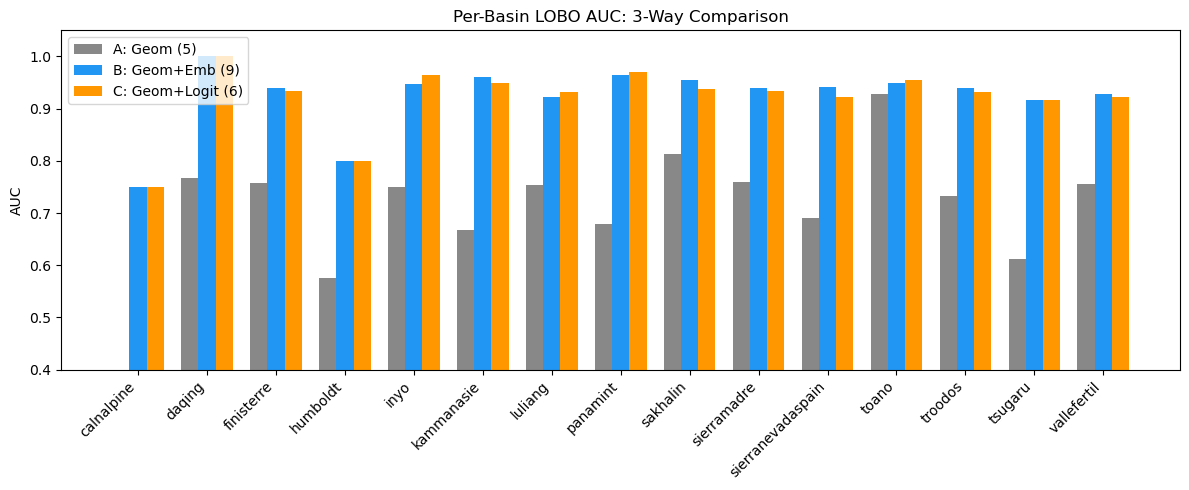

In [7]:
common = sorted(set(aucs_A) & set(aucs_B) & set(aucs_C))
if common:
    df_cmp = pd.DataFrame({
        "basin": common,
        "A: Geom (5)": [aucs_A[b] for b in common],
        "B: Geom+Emb (9)": [aucs_B[b] for b in common],
        "C: Geom+Logit (6)": [aucs_C[b] for b in common],
    }).set_index("basin").sort_index()

    print(df_cmp.to_string(float_format="%.3f"))
    print(f"\nBasins where C > A: {(df_cmp['C: Geom+Logit (6)'] > df_cmp['A: Geom (5)']).sum()}/{len(common)}")
    print(f"Basins where B > A: {(df_cmp['B: Geom+Emb (9)'] > df_cmp['A: Geom (5)']).sum()}/{len(common)}")

    # Bar chart
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(len(common))
    w = 0.25
    ax.bar(x - w, df_cmp["A: Geom (5)"], w, label="A: Geom (5)", color="#888")
    ax.bar(x, df_cmp["B: Geom+Emb (9)"], w, label="B: Geom+Emb (9)", color="#2196F3")
    ax.bar(x + w, df_cmp["C: Geom+Logit (6)"], w, label="C: Geom+Logit (6)", color="#FF9800")
    ax.set_xticks(x)
    ax.set_xticklabels(common, rotation=45, ha="right")
    ax.set_ylabel("AUC")
    ax.set_title("Per-Basin LOBO AUC: 3-Way Comparison")
    ax.legend()
    ax.set_ylim(0.4, 1.05)
    plt.tight_layout()
    plt.show()

## 5. Taiwan Holdout

In [8]:
# Train XGBoost on all CV data, test on Taiwan holdout
y_train = df_cv["y"].values
y_test = df_ho["y"].values
n_pos = y_train.sum()
spw = (len(y_train) - n_pos) / max(n_pos, 1)

xgb_params = dict(
    n_estimators=200, max_depth=4, learning_rate=0.1,
    scale_pos_weight=spw, random_state=RANDOM_STATE,
    n_jobs=-1, eval_metric="logloss",
)

results = {}
for name, feats in [("A: Geom (5)", feat_A), ("B: Geom+Emb (9)", feat_B), ("C: Geom+Logit (6)", feat_C)]:
    mdl = XGBClassifier(**xgb_params)
    mdl.fit(df_cv[feats].values, y_train)
    proba = mdl.predict_proba(df_ho[feats].values)[:, 1]
    pred = (proba >= 0.5).astype(int)
    
    auc = roc_auc_score(y_test, proba) if len(np.unique(y_test)) > 1 else float("nan")
    acc = accuracy_score(y_test, pred)
    results[name] = {"auc": auc, "acc": acc, "proba": proba, "model": mdl}
    print(f"{name:25s}  AUC={auc:.3f}  Acc={acc:.3f}")

print(f"\nTaiwan test set: {len(y_test):,} rows, {y_test.mean():.1%} touching")

A: Geom (5)                AUC=0.772  Acc=0.701
B: Geom+Emb (9)            AUC=0.947  Acc=0.866
C: Geom+Logit (6)          AUC=0.934  Acc=0.846

Taiwan test set: 2,729 rows, 38.6% touching


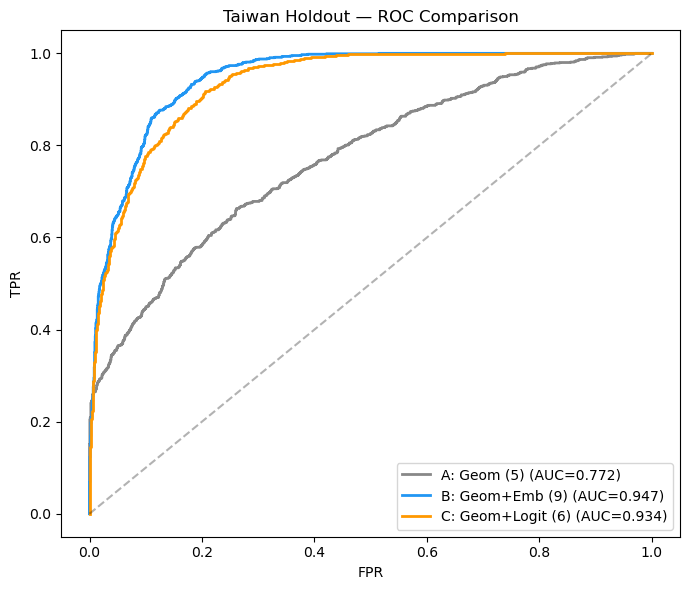

In [9]:
# ROC curves — Taiwan holdout
if len(np.unique(y_test)) > 1:
    fig, ax = plt.subplots(figsize=(7, 6))
    colors = {"A: Geom (5)": "#888", "B: Geom+Emb (9)": "#2196F3", "C: Geom+Logit (6)": "#FF9800"}
    for name, r in results.items():
        fpr, tpr, _ = roc_curve(y_test, r["proba"])
        ax.plot(fpr, tpr, label=f"{name} (AUC={r['auc']:.3f})", linewidth=2, color=colors[name])
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.set_title("Taiwan Holdout — ROC Comparison")
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

## 6. Feature Importance

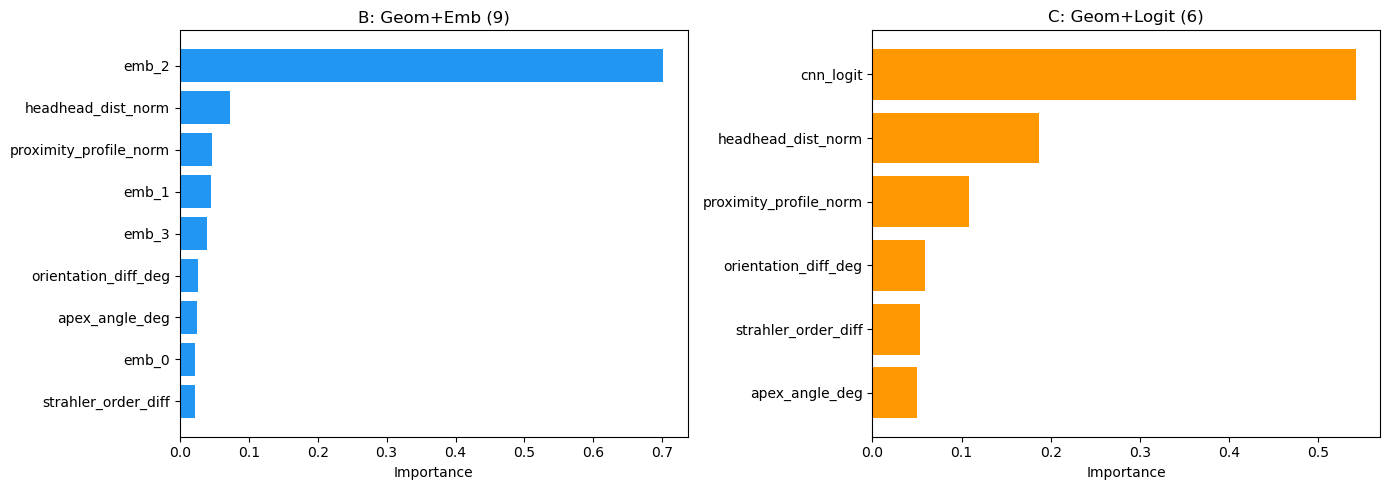

In [10]:
# Feature importance for Model B (9 features) and Model C (6 features)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, feats) in zip(axes, [("B: Geom+Emb (9)", feat_B), ("C: Geom+Logit (6)", feat_C)]):
    mdl = results[name]["model"]
    imp = mdl.feature_importances_
    idx = np.argsort(imp)
    ax.barh(np.array(feats)[idx], imp[idx], color="#2196F3" if "Emb" in name else "#FF9800")
    ax.set_xlabel("Importance")
    ax.set_title(name)

plt.tight_layout()
plt.show()

## 7. Summary

| Model | Features | LOBO CV AUC | Taiwan AUC |
|-------|----------|-------------|------------|
| A | 5 geometric | see above | see above |
| B | 5 geometric + 4 CNN embeddings | see above | see above |
| C | 5 geometric + 1 CNN logit | see above | see above |

**If Model C >= Model B**, the 4-dim embedding is redundant — the CNN's classification head already captures the spatial signal in a single number, and the extra dimensions just add noise for XGBoost.

**If Model B > Model C**, the embedding carries richer spatial information than a single scalar, and the full 4-dim representation is worth the complexity.

**Next steps:** If results look promising, re-run `04_cnn_embeddings.ipynb` with proper per-fold CNN training for publication-quality numbers.